In [70]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import  StandardScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score

# Question 1

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# ---------------- ساخت دیتافریم ----------------
apartment_data = pd.DataFrame()

apartment_data["area_sqm"] = [44.5,132.5,89.8,125.4,157.2,102.3,97.6,44.0,68.6,97.5,119.9,135.5,82.6,43.2,71.0,148.7,61.7,91.5,
151.4,38.1,110.1,153.8,63.8,103.6,148.6,51.6,100.4,128.8,118.6,93.5,60.6,96.3,81.5,94.7,80.7,139.7,131.1,74.2,106.6,69.5,91.6,79.1,117.2,81.3,92.4,124.9,86.6,148.3,57.6,127.6,87.8,88.3,114.3,100.0]

apartment_data["rooms"] = [1,1,2,4,2,2,1,4,3,3,1,1,2,1,4,4,4,1,1,4,1,3,3,3,4,4,4,2,3,4,4,2,1,1,4,2,1,3,3,2,3,2,1,4,4,2,3,4,2,1,1,2,2,2,3]

apartment_data["distance_to_center_km"] = [13.2,21.8,11.8,3.2,20.1,12.7,5.3,22.0,7.1,6.3,9.6,10.0,6.2,4.8,10.3,21.1,19.8,16.2,12.7,12.1,12.1,23.6,18.6,1.5,19.1,13.1,4.9,10.1,23.5,5.7,20.4,10.4,14.9,5.1,20.4,14.7,11.4,20.1,13.8,10.8,1.0,17.3,12.5,5.9,14.0,13.3,12.4,6.9,13.4,24.6,15.8,15.9,22.8,24.1]

apartment_data["building_age_years"] = [10,27,28,8,33,25,28,7,15,0,18,0,9,34,5,21,16,11,32,5,28,29,31,7,28,14,13,19,13,24,3,7,32,33,11,27,4,31,30,14,12,16,26,32,33,8,30,33,15,22,34,12,4,20,18]

apartment_data["rent_price_thousand_toman"] = [1284,3486,2732,4601,4430,3150,2904,1571,2450,3329,3539,4137,2693,1310,2663,4535,1995,2717,4415,1535,3124,4563,1872,3751,4547,1795,3579,3956,3533,3271,2172,3011,2084,2850,2656,4088,3925,2072,3367,2227,3382,2322,3353,2796,3067,3921,2639,4860,1704,3363,2388,2556,3448]

print(apartment_data.head())
apartment_data.info()

# ---------------- جدا کردن ویژگی‌ها و هدف ----------------
x = apartment_data.drop(["rent_price_thousand_toman"], axis=1)
y = apartment_data["rent_price_thousand_toman"]

print(x.shape)
print(y.shape)

# ---------------- تقسیم داده به آموزش/تست ----------------
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------- رگرسیون خطی (بدون مقیاس‌بندی) ----------------
model = LinearRegression()
model.fit(x_train, y_train)

y_perd = model.predict(x_test)

MAE = mean_absolute_error(y_test, y_perd)
MSE = mean_squared_error(y_test, y_perd)
R2 = r2_score(y_test, y_perd)

print(MAE)
print(MSE)
print(R2)

coef = model.coef_
print(coef)

# ---------------- نمودار مقادیر واقعی vs پیش‌بینی ----------------
plt.scatter(y_test, y_perd)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# ---------------- مقیاس‌بندی داده‌ها ----------------
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

# ---------------- رگرسیون خطی (با مقیاس‌بندی) ----------------
model_scaled = LinearRegression()
model_scaled.fit(x_train_scaled, y_train)

y_perd_scale = model_scaled.predict(x_test_scaled)

MAE = mean_absolute_error(y_test, y_perd_scale)
MSE = mean_squared_error(y_test, y_perd_scale)
R2 = r2_score(y_test, y_perd_scale)

print(MAE)
print(MSE)
print(R2)

coef_scaled = model_scaled.coef_
print(coef_scaled)

# ---------------- درخت تصمیم (طبقه‌بند) ----------------
tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)

print(tree.feature_importances_)

ValueError: Length of values (55) does not match length of index (54)

# Question 2

,tenure_months,monthly_usage_min,data_usage_gb,complaints_count,churned
0,25,175.2,28.1,0,0
1,4,138.5,19.6,0,0
2,57,98.1,11.8,3,1
3,1,120.8,33.4,1,1
4,22,451.6,35.0,1,0


,tenure_months,monthly_usage_min,data_usage_gb,complaints_count,churned
count,85.000000,85.000000,85.000000,85.000000,85.000000
mean,35.600000,390.956471,17.810588,1.047059,0.164706
std,19.111951,247.160019,11.349575,0.962461,0.373116
min,1.000000,0.700000,0.500000,0.000000,0.000000
25%,21.000000,158.200000,7.800000,0.000000,0.000000
50%,37.000000,394.600000,17.700000,1.000000,0.000000
75%,51.000000,590.000000,27.900000,2.000000,0.000000
max,70.000000,778.200000,39.100000,4.000000,1.000000


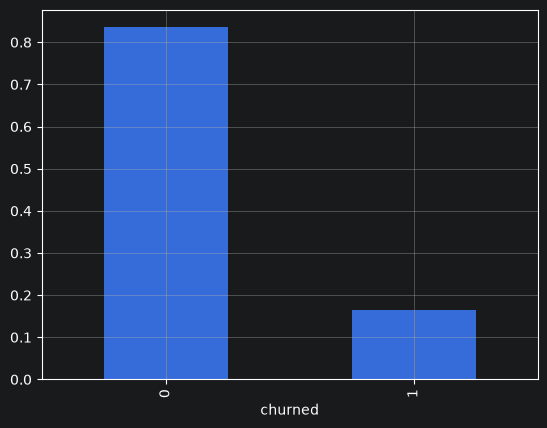

In [34]:
telecom_data = pd.DataFrame()
telecom_data["tenure_months"] = [25,4,57,1,22,20,42,11,22,39,21,45,40,15,27,23,67,3,64,61,2,52,70,30,25,63,8,44,34,49,38,21,50,22
,29,55,1,65,19,64,38,57,57,38,47,34,2,17,33,17,19,56,14,38,31,49,62,34,53,3,29,37,45,49,60,55,22,
57,40,30,33,49,10,34,61,56,12,11,69,45,45,20,17,40,51]
telecom_data["monthly_usage_min"] = [175.2,138.5,98.1,120.8,451.6,166.5,762.6,551.7,442.0,571.6,225.8,742.8,674.6,586.5,394.6,676.8,
600.9,535.1,732.9,514.3,305.4,451.2,173.2,169.8,586.0,632.3,778.2,683.8,444.0,90.0,401.3,743.8,6,
34.3,398.4,375.1,190.0,158.2,77.4,716.1,519.3,131.8,343.0,58.3,183.3,590.0,527.9,393.6,234.3,528,
.7,766.0,359.7,74.7,65.0,84.6,768.6,441.8,673.2,152.6,223.1,559.7,718.5,285.7,70.4,694.0,246.9,59,
8.0,143.3,562.1,676.3,587.2,300.1,586.8,128.8,264.8,347.3,704.2,139.9,706.5,643.2,777.9,306.8,17]
telecom_data["data_usage_gb"] =[28.1,19.6,11.8,33.4,35.0,4.1,9.0,33.4,34.0,12.9,11.5,17.5,21.8,4.3,33.6,21.6,31.1,9.6,38.6,30.2,14.1
,38.0,28.2,33.7,2.3,2.7,29.8,12.5,20.9,6.7,39.1,20.4,33.2,3.4,19.4,3.0,35.4,18.1,3.2,3.5,21.8,3.5,7.8,
17.7,20.2,23.5,25.0,15.2,24.9,6.7,11.4,32.0,6.5,9.3,10.1,19.4,0.5,1.7,18.7,6.9,27.3,31.9,23.3,27.9,15,
.9,2.3,17.9,15.2,24.1,5.8,9.5,32.7,10.9,16.7,37.5,11.4,6.2,28.2,22.9,24.7,2.2,17.0,0.7,10.2]
telecom_data["complaints_count"] = [0,0,3,1,1,1,2,1,1,3,0,1,0,1,1,1,0,4,3,0,1,1,0,1,3,1,1,2,2,1,0,0,0,0,1,2,1,1,0,2,2,0,1,2,2,1,1,2,0,0,0,2,1,2,1,2,0,0,0,1,1,2,0,0,1,0,1,1,2,1,2,0,0,1,1,1,2,1,1,4,2,0,1,0,0]
telecom_data["churned"] = [0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,
1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0]

display(telecom_data.head())
display(telecom_data.describe())
telecom_data["churned"].value_counts(normalize=True).plot(kind="bar")
plt.grid()
plt.show()

In [65]:
print(f"classes percentages: \n{telecom_data["churned"].value_counts(normalize=True)}")

classes percentages: 
churned
0    0.835294
1    0.164706
Name: proportion, dtype: float64


In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    telecom_data.iloc[:,:-1],telecom_data.iloc[:,-1],test_size=0.2,random_state=7,stratify=telecom_data["churned"]
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [40]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)
y_pred = logistic_model.predict(X_test_scaled)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.50      0.33      0.40         3

    accuracy                           0.82        17
   macro avg       0.68      0.63      0.65        17
weighted avg       0.80      0.82      0.81        17



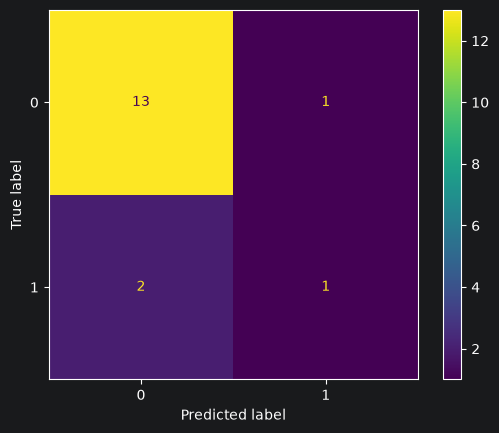

TN:13, FP:1, FN:2, TP:1
0.8235294117647058


In [63]:
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
TN, FP, FN, TP = cm.ravel()


dps = ConfusionMatrixDisplay(cm, display_labels=logistic_model.classes_)
dps.plot()
plt.show()
print(f"TN:{TN}, FP:{FP}, FN:{FN}, TP:{TP}")
acc_fake = accuracy_score(y_test,[0]*len(y_test))
print(acc_fake)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.50      0.33      0.40         3

    accuracy                           0.82        17
   macro avg       0.68      0.63      0.65        17
weighted avg       0.80      0.82      0.81        17



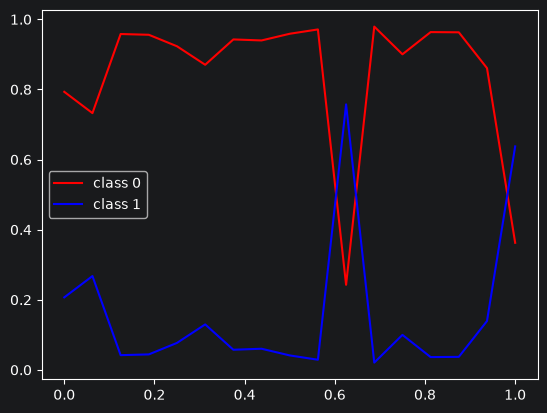

In [83]:
proba = logistic_model.predict_proba(X_test_scaled)
threshold = 0.3
new_pred = np.where(proba[:,1] > threshold, 1, 0)


print(classification_report(y_test,new_pred))

plt.plot(np.linspace(y_test.min(), y_test.max(),len(y_test)), proba[:,0],c="red",label="class 0")
plt.plot(np.linspace(y_test.min(), y_test.max(),len(y_test)), proba[:,1],c="blue",label="class 1")
plt.legend()
plt.show()


In [84]:
proba = logistic_model.predict_proba(X_test_scaled)

confidence = np.abs(proba[:,0] - proba[:,1])
print(confidence)


[0.58640753 0.46482906 0.91612726 0.91183326 0.84623382 0.74070982
 0.88527869 0.87950023 0.91763008 0.94231091 0.51471199 0.95854978
 0.80052174 0.92715603 0.92589634 0.72159234 0.275099  ]
